In [1]:
# Cell 1 Import the tools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

In [2]:
# Cell 2 Load the dataset
df = pd.read_csv("salary_dataset.csv")
df.head()

,Experience Years,Salary
0,0.6,27868
1,0.6,31381
2,0.7,44204
3,0.8,39551
4,0.9,25984


In [3]:
# Cell 3 Check the data
print("Rows and columns:", df.shape)
df.info()
print("Missing values:")
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe()

Rows and columns: (200, 2)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  200 non-null    float64
 1   Salary            200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB
Missing values:
Experience Years    0
Salary              0
dtype: int64
Duplicate rows: 0


,Experience Years,Salary
count,200.000000,200.000000
mean,7.519000,96834.455000
std,4.279792,40938.012116
min,0.600000,25984.000000
25%,3.800000,60248.500000
50%,7.700000,94732.000000
75%,11.500000,132854.500000
max,14.800000,173265.000000


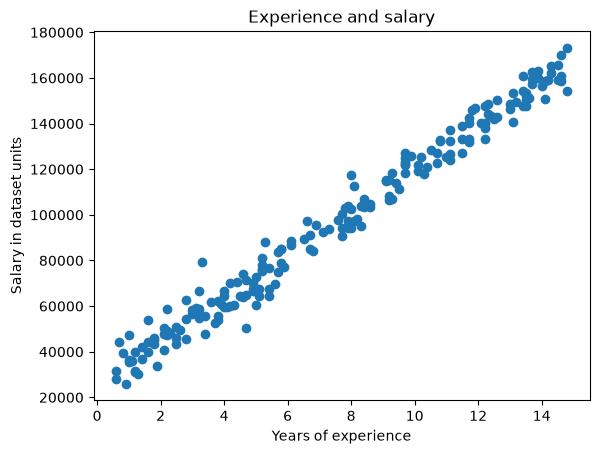

In [4]:
# Cell 4 Explore experience and salary
plt.scatter(df["Experience Years"], df["Salary"])
plt.xlabel("Years of experience")
plt.ylabel("Salary in dataset units")
plt.title("Experience and salary")
plt.show()

In [5]:
# Cell 5 Select input and answer
X = df[["Experience Years"]]
y = df["Salary"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (200, 1)
Target shape: (200,)


In [6]:
# Cell 6 Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 160
Testing rows: 40


In [7]:
# Cell 7 Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9437.99]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience Years']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.576e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [8]:
# Cell 8 Evaluate on held aside rows
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("R squared:", r2)

MAE: 4056.3438613897365
R squared: 0.9831368268457784


In [9]:
# Cell 9 Save the trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Saved model.pkl")


Saved model.pkl


In [10]:
# Cell 10 Load the model and check one prediction
with open("model.pkl", "rb") as file:
    saved_model = pickle.load(file)
sample = pd.DataFrame({"Experience Years": [5.0]})
print("Salary prediction for 5 years:", saved_model.predict(sample)[0])

Salary prediction for 5 years: 72945.11760894189
